In [1]:
import time
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_classification
from sklearn.linear_model import SGDRegressor, LogisticRegression
from dolcestat.preprocessing import DolceSet
from dolcestat.optimization.gradient_descent import GradientDescent
from dolcestat.optimization.newton import NewtonMethod
from dolcestat.optimization.visualizers import OptimizerVisualizer
from dolcestat.optimization.loss_and_activation import compute_mse_loss, compute_bce_loss

FLAVORS = ["batch", "sgd", "mini_batch"]

## Regression

Synthetic dataset: 1 000 samples, 20 features, Gaussian noise.  
Loss function auto-inferred as **MSE** (continuous float target).

We fit the **three gradient-descent flavours** — `batch`, `sgd`, `mini_batch` (10 % of rows) —
overlay their loss curves, and compare against scikit-learn's `SGDRegressor` as a baseline.

In [2]:
X_reg, y_reg = make_regression(n_samples=1000, n_features=20, noise=15, random_state=42)

# Standardize the target too: with a raw target (std ~200) a constant learning
# rate of 0.01 makes the single-sample SGD updates diverge. Scaling y keeps all
# three flavours numerically stable and directly comparable.
y_reg = (y_reg - y_reg.mean()) / y_reg.std()

feature_names = [f"x{i}" for i in range(X_reg.shape[1])]
df_reg = pl.DataFrame({name: X_reg[:, i] for i, name in enumerate(feature_names)})
df_reg = df_reg.with_columns(pl.Series("target", y_reg))

ds_reg = DolceSet()
ds_reg.load_from_polars_dataframe(df_reg, target_col="target")
ds_reg.scale("standardize")

print(f"X shape: {ds_reg.X.shape}  |  y shape: {ds_reg.y.shape}")
ds_reg.df_as_polars.head(3)

X shape: (1000, 20)  |  y shape: (1000,)


x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,target
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.29958,1.615264,-0.137927,0.841452,-0.936231,-1.169805,-1.234378,-1.713806,-0.966257,1.233101,1.612714,1.472379,0.368997,-0.619267,-1.542824,1.011578,1.365562,-1.389715,0.355891,0.198052,0.110231
0.185688,-1.542071,0.227891,-1.629103,0.829396,0.491521,0.300159,-0.065366,0.281481,1.229963,-2.077874,-0.537819,2.705849,-1.859907,0.884273,-1.053447,1.621984,-1.465196,-0.60278,-0.104678,-1.2742
0.530084,-0.099592,-0.720428,0.721406,0.87103,0.273163,0.276098,-1.066268,0.887147,-0.188037,-0.380216,0.382216,1.538126,0.56699,-1.398964,-0.896763,0.526472,0.887082,0.501123,-2.052993,0.935509


In [3]:
gds_reg = {}
for flavor in FLAVORS:
    gd = GradientDescent(
        data=ds_reg, alpha=0.01, n_iters=3000,
        flavor=flavor, batch_fraction=0.1,
    )
    gd.fit()
    gds_reg[flavor] = gd
    print(f"{flavor:>10}  | iters: {len(gd.loss):>4}  | final loss: {gd.get_loss(iteration=-1):.4f}")

     batch  | iters:  273  | final loss: 0.0060
       sgd  | iters:  158  | final loss: 0.0179
mini_batch  | iters:  233  | final loss: 0.0061


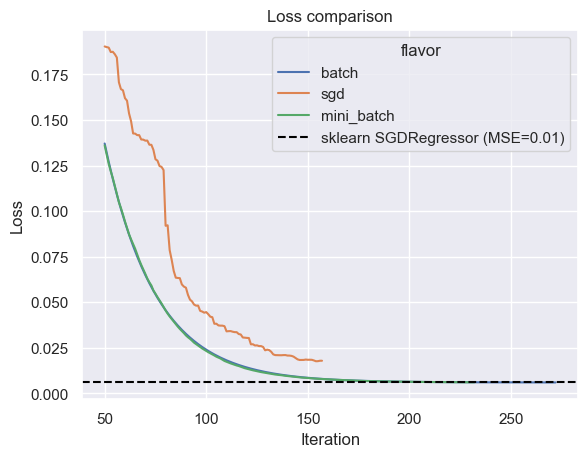

sklearn SGDRegressor final MSE: 0.0063


In [4]:
# sklearn baseline: fit SGDRegressor and measure its MSE on the same data.
sk_reg = SGDRegressor(loss="squared_error", penalty=None, max_iter=3000,
                      tol=1e-6, learning_rate="constant", eta0=0.01,
                      random_state=42)
sk_reg.fit(ds_reg.X, ds_reg.y)
sk_reg_mse = compute_mse_loss(ds_reg.y, sk_reg.predict(ds_reg.X))

# Overlay the three flavours, with the sklearn baseline as a reference line.
gdv_reg = OptimizerVisualizer(list(gds_reg.values()))
ax = gdv_reg.plot_loss(from_iter=50)
ax.axhline(sk_reg_mse, color="black", linestyle="--",
           label=f"sklearn SGDRegressor (MSE={sk_reg_mse:.2f})")
ax.legend(title="flavor")
plt.show()

print(f"sklearn SGDRegressor final MSE: {sk_reg_mse:.4f}")

**Reading the comparison.** `batch` uses every row each step, so its loss curve is the
smoothest and most stable. `sgd` updates from a single random row per step — fastest per
iteration but the noisiest curve. `mini_batch` (10 % of rows) sits in between: most of the
smoothing of batch with cheaper steps. All three should converge toward the sklearn baseline.

In [5]:
# Compare final weights of the batch flavour against sklearn's coefficients.
final_weights_reg = gds_reg["mini_batch"].get_weights(iteration=-1)
weight_names = list(ds_reg.get_features()) + ["bias"]
sk_coef = list(sk_reg.coef_) + [sk_reg.intercept_[0]]
print(f"{'feature':>6} | {'dolcestat (mini-batch)':>18} | {'sklearn':>10}")
for name, w, sk_w in zip(weight_names, final_weights_reg, sk_coef):
    print(f"{name:>7} | {w:+22.4f} | {sk_w:+10.4f}")

feature | dolcestat (mini-batch) |    sklearn
     x0 |                +0.4076 |    +0.4162
     x1 |                +0.4782 |    +0.4851
     x2 |                +0.0281 |    +0.0254
     x3 |                +0.0015 |    +0.0018
     x4 |                +0.4361 |    +0.4331
     x5 |                -0.0032 |    -0.0019
     x6 |                +0.3569 |    +0.3581
     x7 |                -0.0007 |    +0.0029
     x8 |                +0.0008 |    -0.0058
     x9 |                -0.0018 |    +0.0039
    x10 |                +0.0968 |    +0.0987
    x11 |                +0.2026 |    +0.1983
    x12 |                +0.0002 |    -0.0033
    x13 |                +0.0137 |    +0.0071
    x14 |                -0.0044 |    -0.0063
    x15 |                +0.1319 |    +0.1288
    x16 |                -0.0029 |    -0.0027
    x17 |                +0.4388 |    +0.4411
    x18 |                +0.0027 |    +0.0055
    x19 |                +0.0010 |    -0.0008
   bias |                +0.0005 |

## Momentum

Both **Polyak** and **Nesterov** momentum carry a fraction (`momentum_rate`) of the previous
step into the current update, which can accelerate convergence on the regression problem.
We fit `batch` gradient descent with `momentum_type` set to `None`, `"polyak"`, and
`"nesterov"` and overlay their loss curves.

      none  | iters:  273  | final loss: 0.0060
    polyak  | iters:   86  | final loss: 0.0060
  nesterov  | iters:   65  | final loss: 0.0061


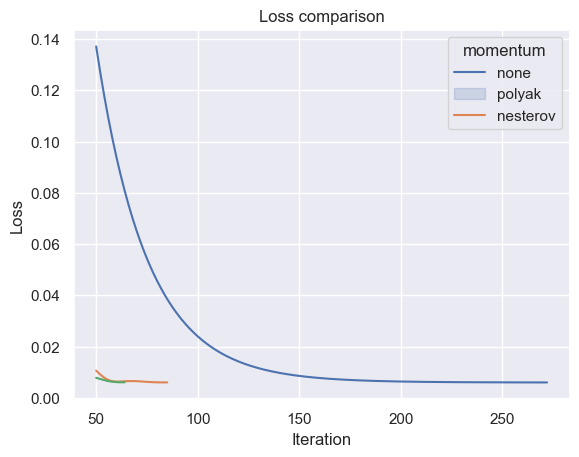

In [6]:
gds_momentum = {}
for momentum_type in [None, "polyak", "nesterov"]:
    gd = GradientDescent(
        data=ds_reg, alpha=0.01, n_iters=3000,
        flavor="batch", momentum_type=momentum_type, momentum_rate=0.9,
    )
    gd.fit()
    label = momentum_type or "none"
    gds_momentum[label] = gd
    print(f"{label:>10}  | iters: {len(gd.loss):>4}  | final loss: {gd.get_loss(iteration=-1):.4f}")

gdv_momentum = OptimizerVisualizer(list(gds_momentum.values()))
ax = gdv_momentum.plot_loss(from_iter=50)
ax.legend(list(gds_momentum.keys()), title="momentum")
plt.show()

## Binary Classification

Synthetic dataset: 1 000 samples, 20 features (10 informative), balanced classes.  
Loss function auto-inferred as **BCE** (binary integer target 0/1). Predictions pass through a
sigmoid, so the loss is a true logistic loss.

Again we fit all **three flavours** and overlay their BCE curves, with scikit-learn's
`LogisticRegression` as the baseline.

In [7]:
X_clf, y_clf = make_classification(
    n_samples=1000, n_features=20, n_informative=10, random_state=42
)

df_clf = pl.DataFrame({name: X_clf[:, i] for i, name in enumerate(feature_names)})
df_clf = df_clf.with_columns(pl.Series("target", y_clf))

ds_clf = DolceSet()
ds_clf.load_from_polars_dataframe(df_clf, target_col="target")
ds_clf.scale("standardize")

unique, counts = np.unique(ds_clf.y, return_counts=True)
print(f"Class distribution: {dict(zip(unique.tolist(), counts.tolist()))}")
print(f"X shape: {ds_clf.X.shape}  |  y dtype: {ds_clf.y.dtype}")

Class distribution: {0: 499, 1: 501}
X shape: (1000, 20)  |  y dtype: int64


In [8]:
gds_clf = {}
for flavor in FLAVORS:
    gd = GradientDescent(
        data=ds_clf, alpha=0.01, n_iters=3000,
        flavor=flavor, batch_fraction=0.1,
    )
    gd.fit()
    gds_clf[flavor] = gd
    print(f"{flavor:>10}  | iters: {len(gd.loss):>4}  | final loss: {gd.get_loss(iteration=-1):.4f}")

     batch  | iters: 3000  | final loss: 0.3596
       sgd  | iters:  450  | final loss: 0.4624
mini_batch  | iters: 1877  | final loss: 0.3715


In [9]:
# sklearn baseline: fit LogisticRegression and measure its BCE on the same data.
sk_clf = LogisticRegression(penalty=None, max_iter=3000)
sk_clf.fit(ds_clf.X, ds_clf.y)
sk_clf_proba = sk_clf.predict_proba(ds_clf.X)[:, 1]
sk_clf_bce = compute_bce_loss(ds_clf.y, sk_clf_proba)

# Overlay the three flavours, with the sklearn baseline as a reference line.
gdv_clf = GradientDescentVisualizer(list(gds_clf.values()))
ax = gdv_clf.plot_loss(from_iter=50)
ax.axhline(sk_clf_bce, color="black", linestyle="--",
           label=f"sklearn LogisticRegression (BCE={sk_clf_bce:.3f})")
ax.legend(title="flavor")
plt.show()

print(f"sklearn LogisticRegression final BCE: {sk_clf_bce:.4f}")

NameError: name 'GradientDescentVisualizer' is not defined

In [ ]:
# Compare final weights of the batch flavour against sklearn's coefficients.
final_weights_clf = gds_clf["batch"].get_weights(iteration=-1)
sk_coef_clf = list(sk_clf.coef_[0]) + [sk_clf.intercept_[0]]
print(f"{'feature':>6} | {'dolcestat (batch)':>18} | {'sklearn':>10}")
for name, w, sk_w in zip(weight_names, final_weights_clf, sk_coef_clf):
    print(f"{name:>6} | {w:+18.4f} | {sk_w:+10.4f}")

feature |  dolcestat (batch) |    sklearn
    x0 |            -0.0868 |    -0.0749
    x1 |            -0.0481 |    -0.0713
    x2 |            +0.6598 |    +0.9755
    x3 |            -0.3584 |    -0.4805
    x4 |            -0.0313 |    -0.0241
    x5 |            -1.4105 |    -1.8659
    x6 |            +0.0981 |    +0.1216
    x7 |            -0.3776 |    -0.3501
    x8 |            +0.0213 |    +0.0031
    x9 |            -0.0301 |    -0.0372
   x10 |            +0.6333 |    +0.9703
   x11 |            +0.0321 |    +0.0409
   x12 |            +1.1097 |    +1.5154
   x13 |            +0.0848 |    +0.0839
   x14 |            +0.3168 |    +0.2223
   x15 |            +0.5112 |    +0.6369
   x16 |            -0.6093 |    -0.7417
   x17 |            -0.0888 |    -0.0871
   x18 |            +0.4653 |    +0.6840
   x19 |            -0.1635 |    -0.1024
  bias |            -0.1022 |    -0.2118


---
## GD vs Newton Method — head-to-head comparison

We run **Batch Gradient Descent** and **Newton's Method** on the same regression and
classification datasets used above, and compare them on two axes:

1. **Wall-clock time** to reach convergence (or exhaust `n_iters`).
2. **Loss value as a function of the number of iterations.**

Newton's Method uses exact second-order curvature information (the Hessian) to take
a single, precisely scaled step per iteration, while GD follows the plain gradient
scaled by a fixed learning rate `α`.  The trade-off is that each Newton step is
significantly more expensive ($O(d^3)$ inversion) but the method typically needs far
fewer iterations to converge.

### Regression — timing & convergence

Same 1 000-sample, 20-feature dataset as before (standardized targets).

In [ ]:
def timed_fit(optimizer):
    """Fit an optimizer and return (elapsed_seconds, optimizer)."""
    t0 = time.perf_counter()
    optimizer.fit()
    return time.perf_counter() - t0, optimizer


gd_reg = GradientDescent(
    data=ds_reg, alpha=0.01, n_iters=3000, flavor="batch"
)
gd_reg_opt = GradientDescent(
    data=ds_reg, alpha=0.01, n_iters=3000, flavor="mini_batch", momentum_type='polyak'
)
newton_reg = NewtonMethod(data=ds_reg, n_iters=3000)

t_gd_reg,     _ = timed_fit(gd_reg)
t_gd_reg_opt, _ = timed_fit(gd_reg_opt)
t_newton_reg, _ = timed_fit(newton_reg)

print(f"{'Optimizer':<25} {'Iters':>6} {'Final loss':>12} {'Time (s)':>10}")
print("-" * 57)
for label, opt, t in [
    ("GD (batch)",    gd_reg,     t_gd_reg),
    ("GD (mini-batch w/Polyak)",    gd_reg_opt,     t_gd_reg_opt),
    ("Newton Method", newton_reg, t_newton_reg),
]:
    n = len(opt.loss)
    print(f"{label:<25} {n:>6} {opt.get_loss(-1):>12.6f} {t:>10.4f}")

Optimizer                  Iters   Final loss   Time (s)
---------------------------------------------------------
GD (batch)                   273     0.006003     1.3070
GD (mini-batch w/Polyak)     115     0.006114     0.1581
Newton Method                  3     0.005977     0.0040


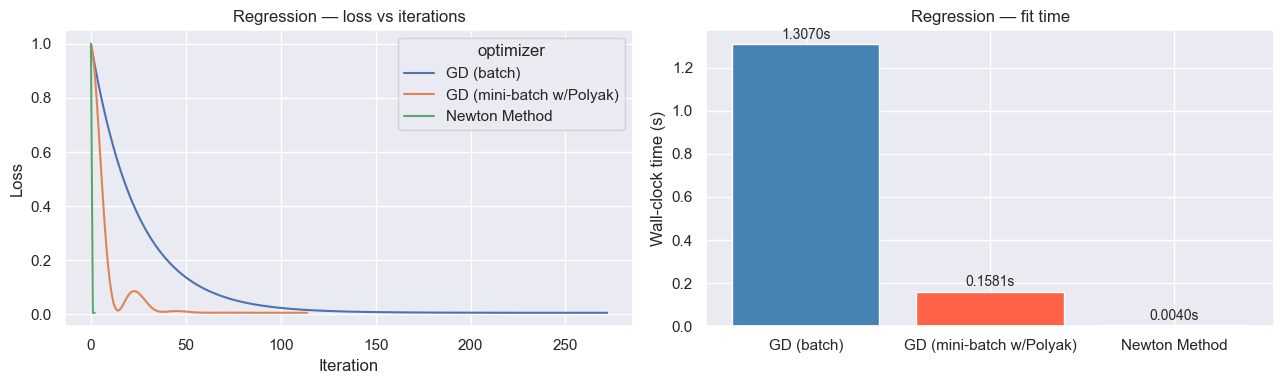

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left: loss vs iterations ---
viz_reg = OptimizerVisualizer(
    [gd_reg, gd_reg_opt, newton_reg],
    labels=["GD (batch)", "GD (mini-batch w/Polyak)", "Newton Method"],
)
viz_reg.plot_loss(ax=axes[0])
axes[0].set_title("Regression — loss vs iterations")

# --- Right: wall-clock timing bar chart ---
times = {"GD (batch)": t_gd_reg, "GD (mini-batch w/Polyak)": t_gd_reg_opt, "Newton Method": t_newton_reg}
axes[1].bar(times.keys(), times.values(), color=["steelblue", "tomato", "green"])
axes[1].set_ylabel("Wall-clock time (s)")
axes[1].set_title("Regression — fit time")
for i, (k, v) in enumerate(times.items()):
    axes[1].text(i, v + max(times.values()) * 0.01, f"{v:.4f}s",
                 ha="center", va="bottom", fontsize=10)

fig.tight_layout()
plt.show()

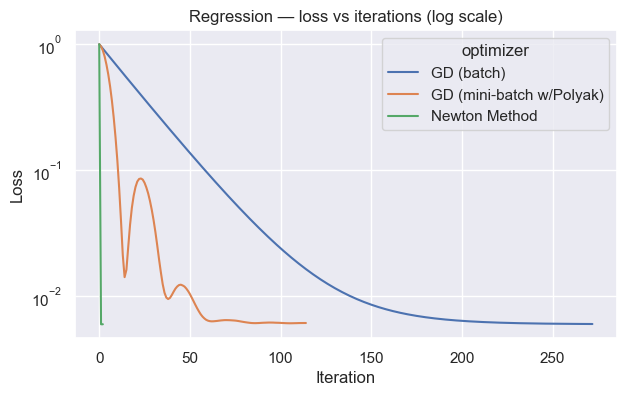

In [ ]:
# Log-scale view: makes early-iteration behaviour more readable
fig, ax = plt.subplots(figsize=(7, 4))
viz_reg.plot_loss(log_scale=True, ax=ax)
ax.set_title("Regression — loss vs iterations (log scale)")
plt.show()

**Reading the regression comparison.**  
Newton's Method typically converges in a handful of iterations because it uses the full
curvature of the MSE surface.  Batch GD needs many more steps to 'zig-zag' its way to the same minimum.
The bar chart shows the per-run wall-clock cost: each Newton step inverts a
$(d+1)\\times(d+1)$ matrix, which for $d = 20$ is cheap — but for very large $d$ that
cost grows cubically and would quickly dwarf GD's savings in iteration count.

### Binary Classification — timing & convergence

Same 1 000-sample, 20-feature classification dataset (BCE loss, sigmoid activation).

In [ ]:
gd_clf = GradientDescent(
    data=ds_clf, alpha=0.01, n_iters=3000, flavor="batch"
)
newton_clf = NewtonMethod(data=ds_clf, n_iters=3000)

t_gd_clf,     _ = timed_fit(gd_clf)
t_newton_clf, _ = timed_fit(newton_clf)

print(f"{'Optimizer':<20} {'Iters':>6} {'Final loss':>12} {'Time (s)':>10}")
print("-" * 52)
for label, opt, t in [
    ("GD (batch)",    gd_clf,     t_gd_clf),
    ("Newton Method", newton_clf, t_newton_clf),
]:
    n = len(opt.loss)
    print(f"{label:<20} {n:>6} {opt.get_loss(-1):>12.6f} {t:>10.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left: loss vs iterations ---
viz_clf = OptimizerVisualizer(
    [gd_clf, newton_clf],
    labels=["GD (batch)", "Newton Method"],
)
viz_clf.plot_loss(ax=axes[0])
axes[0].set_title("Classification — loss vs iterations")

# --- Right: timing bar chart ---
times = {"GD (batch)": t_gd_clf, "Newton Method": t_newton_clf}
axes[1].bar(times.keys(), times.values(), color=["steelblue", "tomato"])
axes[1].set_ylabel("Wall-clock time (s)")
axes[1].set_title("Classification — fit time")
for i, (k, v) in enumerate(times.items()):
    axes[1].text(i, v + max(times.values()) * 0.01, f"{v:.4f}s",
                 ha="center", va="bottom", fontsize=10)

fig.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
viz_clf.plot_loss(log_scale=True, ax=ax)
ax.set_title("Classification — loss vs iterations (log scale)")
plt.show()

**Reading the classification comparison.**  
For logistic regression the Hessian is $X^\\top W X / n$ where $W = \\text{diag}(p(1-p))$
changes every iteration — Newton's Method still converges much faster than GD in
iteration count (quadratic vs linear convergence near the optimum), but each step
requires recomputing and inverting the Hessian.  
The timing bar shows how this per-step cost compares against GD's cheaper-but-more-
numerous gradient updates.

### Summary table

In [ ]:
rows = []
for task, gd_opt, nt_opt, gd_t, nt_t in [
    ("Regression",      gd_reg, newton_reg, t_gd_reg,  t_newton_reg),
    ("Classification",  gd_clf, newton_clf, t_gd_clf,  t_newton_clf),
]:
    for label, opt, t in [("GD (batch)", gd_opt, gd_t), ("Newton", nt_opt, nt_t)]:
        rows.append({
            "Task": task,
            "Optimizer": label,
            "Iterations": len(opt.loss),
            "Final loss": round(float(opt.get_loss(-1)), 6),
            "Time (s)": round(t, 4),
        })

summary = pl.DataFrame(rows)
print(summary)

In [10]:
X1 = np.array([[1,2,3],[4,5,6]])
X2 = np.array([[6,3,6],[6,4,5],[0,9,4],[2,2,2]])

In [21]:
dist_matrix = []
for x1 in X1:
    row = []
    for x2 in X2:
        row.append(np.abs(np.sum(x1 - x2)))
    dist_matrix.append(row)

In [ ]:
for row in dist_matrix:
    print(row)
    print(sorted(range(len(row)), key=row.__getitem__)[:2])


# 1. Extract indexes of smallest distaces
# 2. Extract y associated with indexes
# 3. Compute either mode or average

[9, 9, 7, 0]
[3, 2]
[0, 0, 2, 9]
[0, 1]
